In [8]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Amazon Sale Report.csv', low_memory=False)

# 2. Check rows and columns count
print("Dataset Shape:", df.shape)

# 3. Check columns and data types
print("\n--- Dataset Info ---")
print(df.info())

# 4. View first 5 rows
df.head()

Dataset Shape: (128975, 24)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-nul

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [9]:
# 1. Check total count of missing fields per column
print("Missing values per column before cleaning:")
print(df.isnull().sum())

# 2. Drop columns that are completely empty if any exist
df = df.dropna(how='all')

# 3. Handle duplicate records to secure analytical integrity
print(f"\nTotal duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# 4. Check for critical status/numerical columns and clean missing rows
# Drop rows where critical info like 'Amount' or 'Status' is blank
if 'Amount' in df.columns:
    df = df.dropna(subset=['Amount'])

print("\nData Cleaning Completed successfully!")
print("New Cleaned Dataset Shape:", df.shape)

Missing values per column before cleaning:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

Total duplicate rows found: 0

Data Cleaning Completed successfully!
New Cleaned Dataset Shape: (121180, 24)


In [10]:
import pandas as pd

# 1. Generate descriptive summary statistics for numerical variables
print("--- Statistical Summary ---")
print(df.describe())

# 2. Categorical dynamic frequency distribution
# Checking performance variations across Order Status profiles
if 'Status' in df.columns:
    print("\n--- Order Status Distribution Count ---")
    print(df['Status'].value_counts().head(10))


--- Statistical Summary ---
               index            Qty         Amount  ship-postal-code
count  121180.000000  121180.000000  121180.000000     121149.000000
mean    64483.115877       0.961231     648.561465     463652.687525
std     37222.531993       0.214354     281.211687     191316.128616
min         0.000000       0.000000       0.000000     110001.000000
25%     32285.750000       1.000000     449.000000     382421.000000
50%     64474.500000       1.000000     605.000000     500032.000000
75%     96680.250000       1.000000     788.000000     600021.000000
max    128974.000000       8.000000    5584.000000     989898.000000

--- Order Status Distribution Count ---
Status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller 

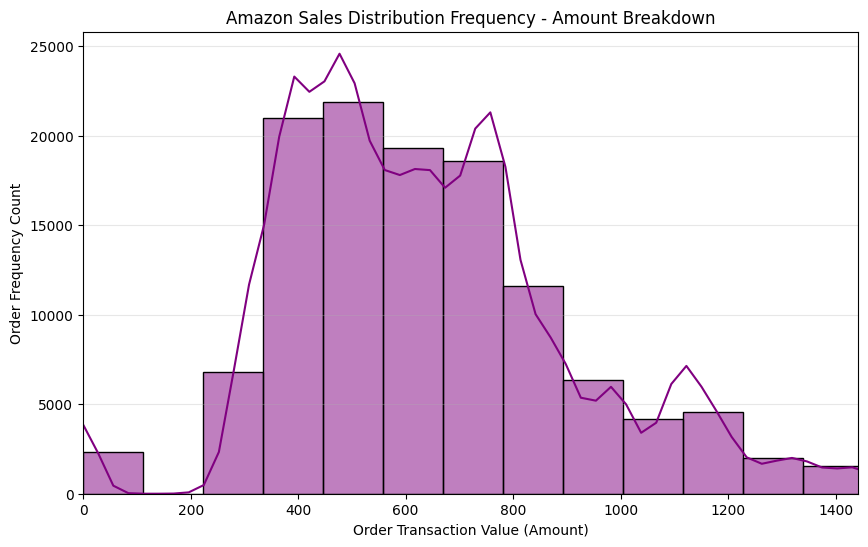

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize visualization environment setup
plt.figure(figsize=(10, 6))

# 2. If 'Amount' distribution column exists, plot structural density histogram
if 'Amount' in df.columns:
    sns.histplot(df['Amount'], bins=50, kde=True, color='purple')
    plt.title('Amazon Sales Distribution Frequency - Amount Breakdown')
    plt.xlabel('Order Transaction Value (Amount)')
    plt.ylabel('Order Frequency Count')

    # Dynamic scaling for long-tail outliers mapping
    plt.xlim(0, df['Amount'].quantile(0.99))
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("Specified dynamic metric column not detected for plotting.")